In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestPower

In [2]:
#A researcher presents you with the following data Yi, i = 1, 2, . . . 36, which is independent and identically normally distributed with a mean μ and variance σ2

In [3]:
data = np.arange(1, 37, 1)

In [4]:
#Set up the rejection region for testing the hypotheses H0 : μ = 10 vs H1 : μ̸ = 10, based on Y1, . . . , Y36 and α = 0.05. Assume σ is unknown

In [5]:
n = 36
DoF = n - 1
alpha = .05
tcritical = stats.t.ppf(1 - alpha/2, DoF)
null = 10
std = stats.tstd(data)
rejectionLower, rejectionUpper = null - tcritical * (std/np.sqrt(n)), null + tcritical * (std/np.sqrt(n))
print(f"{rejectionLower}, {rejectionUpper}")

6.435247631172198, 13.564752368827802


In [6]:
#Calculate the power of your test for the following values of the true parameter μ: 9.6, 9.7, 9.8, 9.9, 9.95, 10, 10.05, 10.1, 10.2, 10.3, 10.4
#Researcher gives σ = 0.27
std = 0.27
se = std/np.sqrt(n)
rejectionLower, rejectionUpper = null - tcritical * se, null + tcritical * se

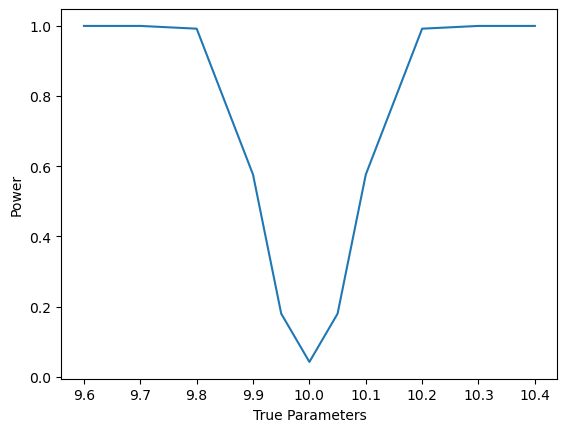

In [7]:
testparameters = [9.6, 9.7, 9.8, 9.9, 9.95, 10, 10.05, 10.1, 10.2, 10.3, 10.4]
powers = []
for parameter in testparameters:
    power = stats.norm.cdf(rejectionLower, loc=parameter, scale=se) + (1-stats.norm.cdf(rejectionUpper, loc=parameter, scale=se))
    powers.append(power)
graphdata = np.column_stack((testparameters, powers))  
plt.plot(graphdata[:,0], graphdata[:, 1])
plt.xlabel("True Parameters")
plt.ylabel("Power")
plt.show()

In [8]:
#Determine the necessary sample size so that the power at μ = 10.2 is at least 0.80 for a level α = .05 test of H0 : μ ≤ 10 vs H1 : μ > 10.

In [9]:
#manual 
H0 = 10
HA = 10.2
zalpha = stats.norm.ppf(.95)
zbeta = stats.norm.ppf(.80)
delta = abs(H0-HA)
std = 0.27

nNeeded = ((zalpha + zbeta) * std / delta)**2
int(np.ceil(nNeeded))

12

In [10]:
#Using statsmodels
nNeeded = TTestPower().solve_power(effect_size=abs(H0-HA)/(std), alpha = 0.05, power = .80, alternative = 'larger')
print(int(nNeeded))

12


In [11]:
data = (10.14, 11.38, 10.93, 11.99, 10.15, 10.07, 10.02, 9.44, 9.39, 10.15, 9.94, 9.79, 10.24, 10.06, 11.63, 11.34, 9.88, 9.17, 9.80, 8.70)

In [12]:
#Is there significant evidence (α = .05) that the standard deviation in the readings from the new device is less than 1?

In [13]:
alpha = 0.05
n = len(data)
samplevar = stats.tvar(data)
H0 = 1
teststat = (n - 1)*samplevar/H0
chicrit = stats.chi2.ppf(alpha, n-1)
if teststat < chicrit:
    print("Yes, enough evidence to reject")
else:
    print("No, fail to reject")

No, fail to reject


In [14]:
#Compute the probability of a Type II error in using your test from part 1. for the following values of σ: 0.6, 0.7, 0.8, 0.9, 1

In [15]:
crit = stats.chi2.ppf(alpha, n-1)
alternates = [0.6, 0.7, 0.8, 0.9, 1]
typeIIerrors = []
for alternate in alternates:
    rejectionnull = (crit * H0**2)/(n-1)
    rejectionalternate = (rejectionnull * (n-1)/(alternate**2))
    beta = 1 - stats.chi2.cdf(rejectionalternate, n-1) 
    typeIIerrors.append(float(beta))
typeIIerrors

[0.08146982976240646,
 0.3566315021998612,
 0.6700586362266745,
 0.8636200510911177,
 0.95]

In [16]:
#Construct an upper 90% confidence bound on the standard deviation of the new device

In [17]:
upperBound = np.sqrt(((n-1)*samplevar)/stats.chi2.ppf(.10, (n-1)))
print(f"We are 90% confident that the true standard deviation is less than {upperBound}")
#This is consistent with part 1 as we did not reject then and 1 is within the range of the CI

We are 90% confident that the true standard deviation is less than 1.0801539087588512


In a recent survey conducted by a popular health magazine, researchers were
interested in determining whether the proportion of people who exercise regularly (at least
150 minutes of moderate-intensity aerobic activity or 75 minutes of vigorous-intensity ac-
tivity per week) has increased from last year. Last year, it was reported that 60% of the
magazine’s readership engaged in regular exercise. This year, in a random sample of 200
readers, 130 reported engaging in regular exercise.

In [18]:
pnull = 0.6
alpha = 0.05
n = 200
phat = 130/200

In [19]:
#Place a 95% confidence interval on the proportion of people engaging in regular exercise.

In [20]:
se = np.sqrt((phat*(1-phat))/n)
zcrit = stats.norm.ppf(1-alpha/2)
MoE = zcrit * se
ciLower, ciUpper = phat - MoE, phat + MoE
float(ciLower), float(ciUpper)

(0.5838966006279589, 0.7161033993720411)

In [21]:
#Is there substantial evidence (α = .05) that the proportion of regularly exercising people has increased this year over last year?

In [22]:
print("No, since the 95% CI contains our null hypothesis (0.6, the proportion of people regularly exercising from last year), there is not substantial evidence that the proportion has increased year over year")

No, since the 95% CI contains our null hypothesis (0.6, the proportion of people regularly exercising from last year), there is not substantial evidence that the proportion has increased year over year


In [23]:
#Compute the power of the test in part 2 to detect that the proportion of regularly exercising people is 55%, 60%, 65%, 70%, 75%.

In [24]:
palts = [.55, .6, .65, .7, .75]
powers = []
for palt in palts:
    seAlt = np.sqrt(palt * (1-palt)/n)
    pHigher = 1- stats.norm.cdf(ciUpper, loc=palt, scale=seAlt)
    pLower = stats.norm.cdf(ciLower, loc=palt, scale=seAlt)
    powers.append(float(pHigher + pLower))
powers

[0.8323705438437276,
 0.3214157391771224,
 0.050000000000000024,
 0.3097778489110151,
 0.8658656762723693]